# Non-windowed relative RPKM distributions

The x-axis is relative RPKM and the y-axis is peak count. Real and simulated distributions are generated in separate cells. `NA` values (zero 1m RPKM) are excluded.

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path('/cta/users/guneyn23')
RELATIVE_DIR = BASE / 'non_windowed/nonwindowed_rpkm/relative_rpkm'
PLOT_DIR = BASE / 'non_windowed/distribution_plots'
PEAK_SETS = [
    'noUV_IDR_ATAC',
    '4h_UV_specific',
    '4h_noUV_specific',
    '8h_UV_specific',
    '8h_noUV_specific',
]
DAMAGES = ['CPD', '64']
TIMES = ['15m', '30m', '1h', '4h', '8h']
COLORS = {
    '15m': '#0072B2',
    '30m': '#E69F00',
    '1h': '#009E73',
    '4h': '#D55E00',
    '8h': '#CC79A7',
}
BINS = 80
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def relative_path(peak_set, damage, time, kind):
    return RELATIVE_DIR / f'{peak_set}__{damage}__{time}__{kind}_relative_rpkm.tsv'

def read_relative(path):
    data = pd.read_csv(path, sep='\t', header=None)
    # Relative RPKM is always the final column; NA becomes NaN here.
    values = pd.to_numeric(data.iloc[:, -1], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    # Keep positive relative repair only; negative values mean timepoint RPKM > 1m RPKM.
    return values[values >= 0]

def plot_distributions(kind):
    kind_output = PLOT_DIR / kind
    kind_output.mkdir(parents=True, exist_ok=True)
    saved = []
    for peak_set in PEAK_SETS:
        for damage in DAMAGES:
            distributions = {
                time: read_relative(relative_path(peak_set, damage, time, kind))
                for time in TIMES
            }
            combined = pd.concat(distributions.values(), ignore_index=True)
            if combined.empty:
                raise ValueError(f'No finite values: {peak_set} {damage} {kind}')
            # Identical bin edges make peak counts comparable across timepoints.
            edges = np.linspace(0, 1, BINS + 1)
            maximum_count = max(np.histogram(values, bins=edges)[0].max() for values in distributions.values())
            fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
            for ax, time in zip(axes.flat, TIMES):
                values = distributions[time]
                ax.hist(
                    values, bins=edges, color=COLORS[time],
                    edgecolor='white', linewidth=0.35, alpha=0.9,
                )
                ax.set_title(f'{time} (n={len(values):,})')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, maximum_count * 1.05)
                ax.set_xlabel('Positive relative repair')
                ax.set_ylabel('Peak count')
                ax.grid(axis='y', alpha=0.2)
            axes.flat[-1].set_visible(False)
            label = 'Real' if kind == 'real' else 'Simulated'
            damage_label = '6-4PP' if damage == '64' else 'CPD'
            fig.suptitle(f'{peak_set} | {damage_label} | {label}', fontsize=14)
            fig.tight_layout()
            output = kind_output / f'{peak_set}__{damage}__{kind}_distribution.png'
            fig.savefig(output, dpi=300, bbox_inches='tight')
            plt.show()
            plt.close(fig)
            saved.append(output)
    print(f'Saved {len(saved)} {kind} plots to: {kind_output}')
    return saved

## Total overlap counts across time

Before RPKM calculation, the final `bedtools intersect -c` column is summed for each dataset. The same peak set is compared from 1m through 8h; real and simulated counts are plotted separately.

In [16]:
OVERLAP_DIR = BASE / 'non_windowed/nonwindowed_overlaps'
OVERLAP_TIMES = ['1m', '15m', '30m', '1h', '4h', '8h']
OVERLAP_SAMPLES = {
    ('CPD', '1m'): '1mCPD_GATCAG_S6', ('CPD', '15m'): '15mCPD_TAGCTT_S2',
    ('CPD', '30m'): '30mCPD_GGCTAC_S8', ('CPD', '1h'): '1hCPD_CTTGTA_S4',
    ('CPD', '4h'): '4hCPD_AGTCAA_S10', ('CPD', '8h'): '8hCPD_AGTTCC_S12',
    ('64', '1m'): '1m64_CGATGT_S5', ('64', '15m'): '15m64_TTAGGC_S1',
    ('64', '30m'): '30m64_TGACCA_S7', ('64', '1h'): '1h64_ACAGTG_S3',
    ('64', '4h'): '4h64_GCCAAT_S9', ('64', '8h'): '8h64_CAGATC_S11',
}

def overtime_overlap_path(peak_set, damage, time, kind):
    if peak_set == 'noUV_IDR_ATAC' and time == '1m':
        label = 'simulated' if kind == 'sim' else 'real'
        return OVERLAP_DIR / 'normal_peak_overlaps_1m' / f'ATAC_{damage}_{label}_overlap.bed'
    sample = OVERLAP_SAMPLES[(damage, time)]
    return OVERLAP_DIR / f'{peak_set}__{sample}__{kind}_overlap.bed'

def overlap_count_summary(path):
    data = pd.read_csv(path, sep='\t', header=None)
    counts = pd.to_numeric(data.iloc[:, -1], errors='raise')
    return len(data), int(counts.sum()), int(counts.eq(0).sum())

overlap_summary_rows = []
for peak_set in PEAK_SETS:
    for damage in DAMAGES:
        for kind in ('real', 'sim'):
            for time in OVERLAP_TIMES:
                path = overtime_overlap_path(peak_set, damage, time, kind)
                peaks, total_overlaps, zero_overlap_peaks = overlap_count_summary(path)
                overlap_summary_rows.append({
                    'peak_set': peak_set, 'damage': damage, 'kind': kind, 'time': time,
                    'peaks': peaks, 'total_overlaps': total_overlaps,
                    'zero_overlap_peaks': zero_overlap_peaks, 'overlap_file': str(path),
                })

overtime_overlap_summary = pd.DataFrame(overlap_summary_rows)
overtime_overlap_summary['time'] = pd.Categorical(
    overtime_overlap_summary['time'], categories=OVERLAP_TIMES, ordered=True
)
overtime_overlap_summary_path = PLOT_DIR / 'overtime_total_overlap_counts.tsv'
overtime_overlap_summary.to_csv(overtime_overlap_summary_path, sep='\t', index=False)
print(f'Written: {overtime_overlap_summary_path}')
overtime_overlap_summary

Written: /cta/users/guneyn23/non_windowed/distribution_plots/overtime_total_overlap_counts.tsv


,peak_set,damage,kind,time,peaks,total_overlaps,zero_overlap_peaks,overlap_file
0,noUV_IDR_ATAC,CPD,real,1m,48911,237909,3318,/cta/users/guneyn23/non_windowed/nonwindowed_o...
1,noUV_IDR_ATAC,CPD,real,15m,48911,233740,3540,/cta/users/guneyn23/non_windowed/nonwindowed_o...
2,noUV_IDR_ATAC,CPD,real,30m,48911,265619,2714,/cta/users/guneyn23/non_windowed/nonwindowed_o...
3,noUV_IDR_ATAC,CPD,real,1h,48911,244029,3188,/cta/users/guneyn23/non_windowed/nonwindowed_o...
4,noUV_IDR_ATAC,CPD,real,4h,48911,222879,3671,/cta/users/guneyn23/non_windowed/nonwindowed_o...
...,...,...,...,...,...,...,...,...
115,8h_noUV_specific,64,sim,15m,485,2334,5,/cta/users/guneyn23/non_windowed/nonwindowed_o...
116,8h_noUV_specific,64,sim,30m,485,3551,0,/cta/users/guneyn23/non_windowed/nonwindowed_o...
117,8h_noUV_specific,64,sim,1h,485,1744,8,/cta/users/guneyn23/non_windowed/nonwindowed_o...
118,8h_noUV_specific,64,sim,4h,485,801,94,/cta/users/guneyn23/non_windowed/nonwindowed_o...


### Real total overlap counts

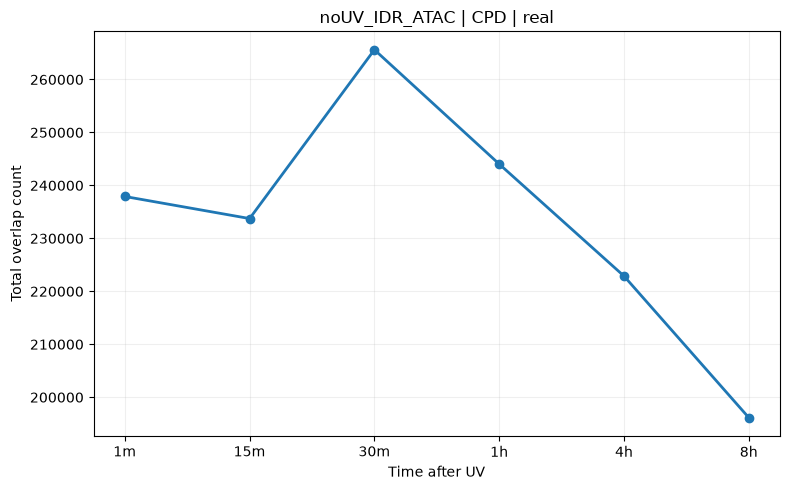

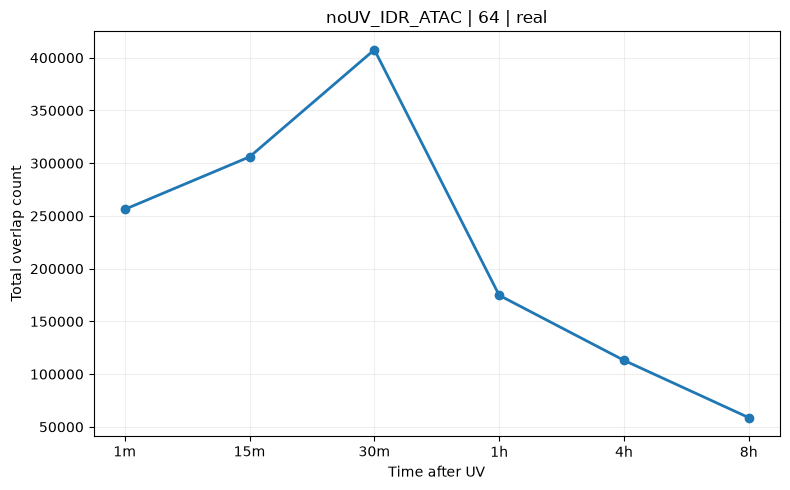

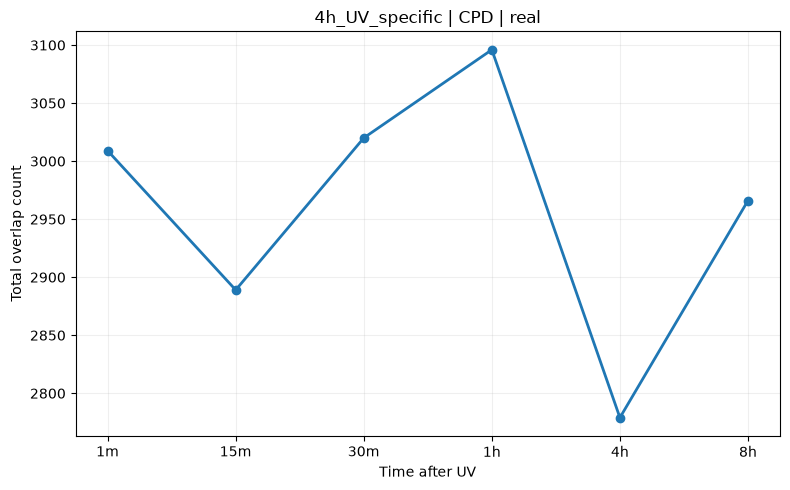

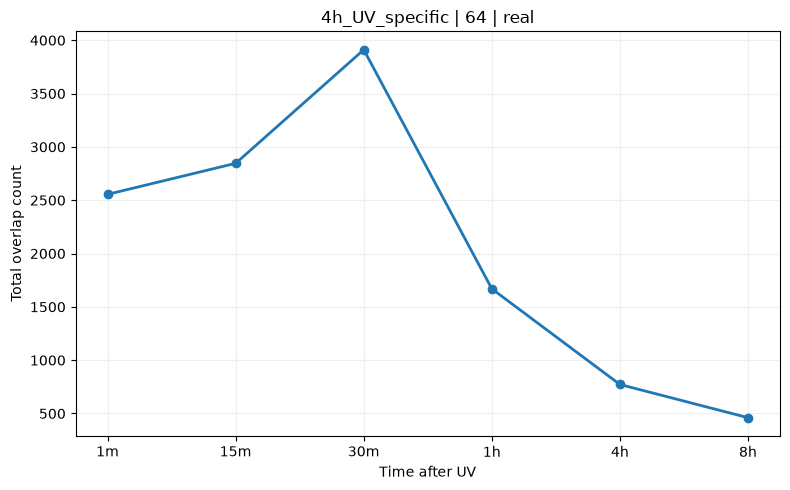

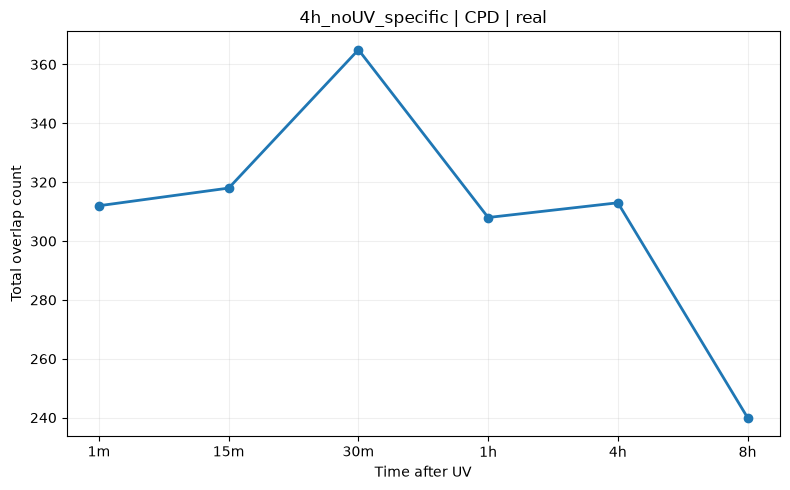

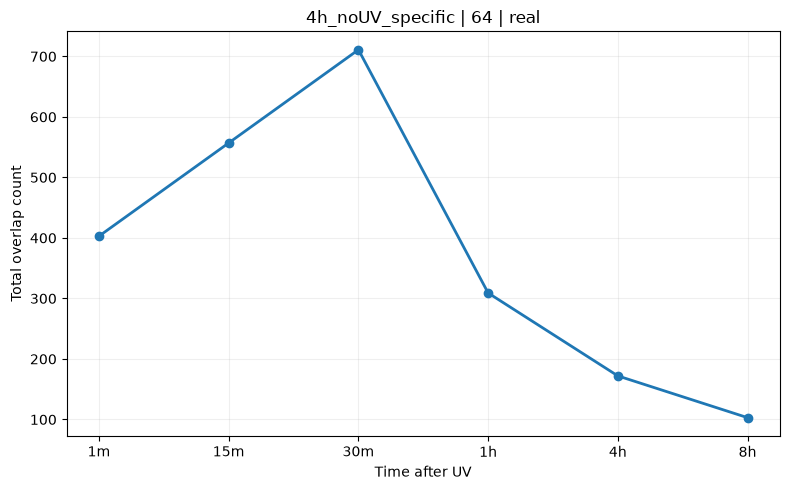

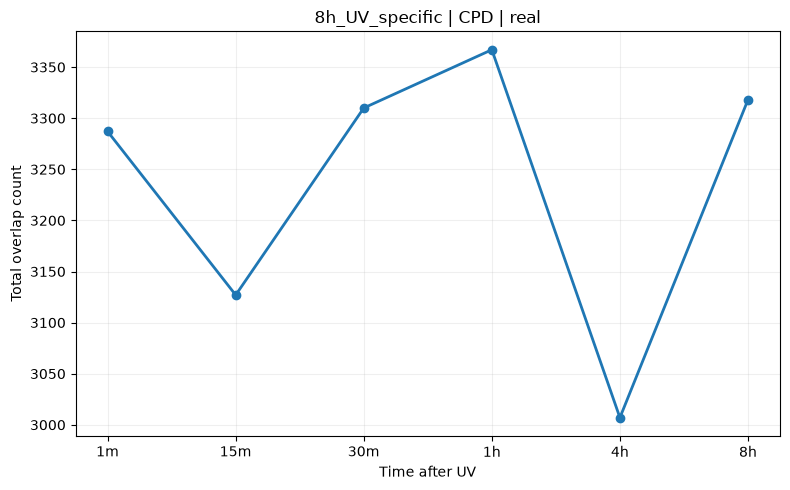

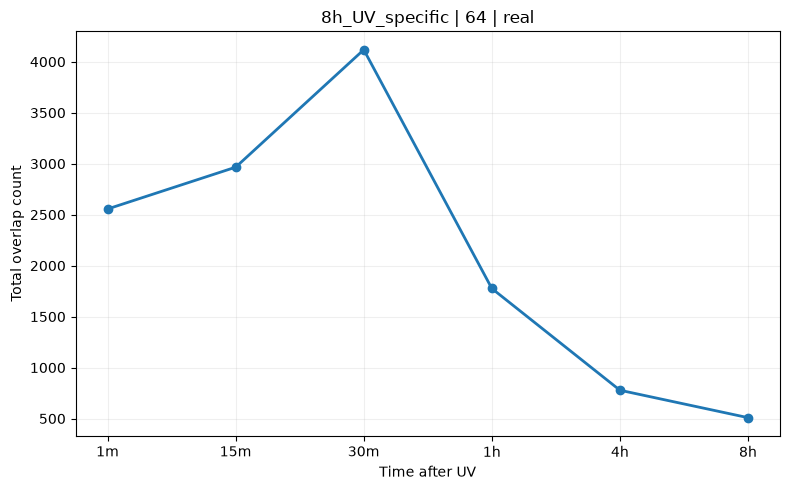

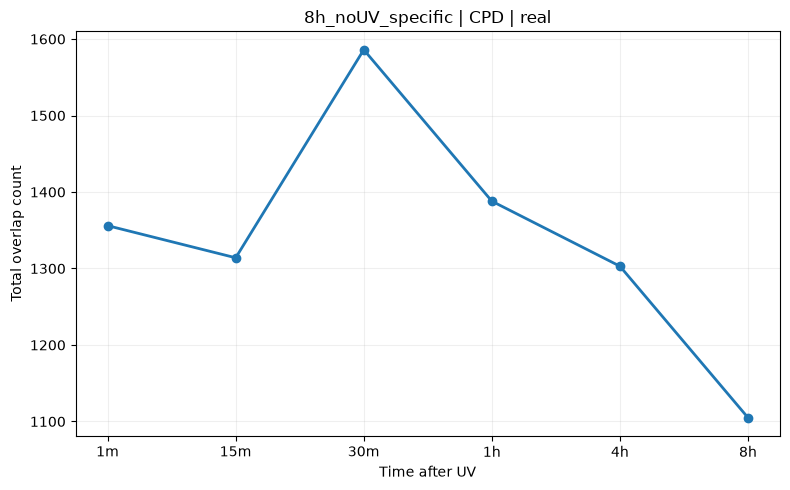

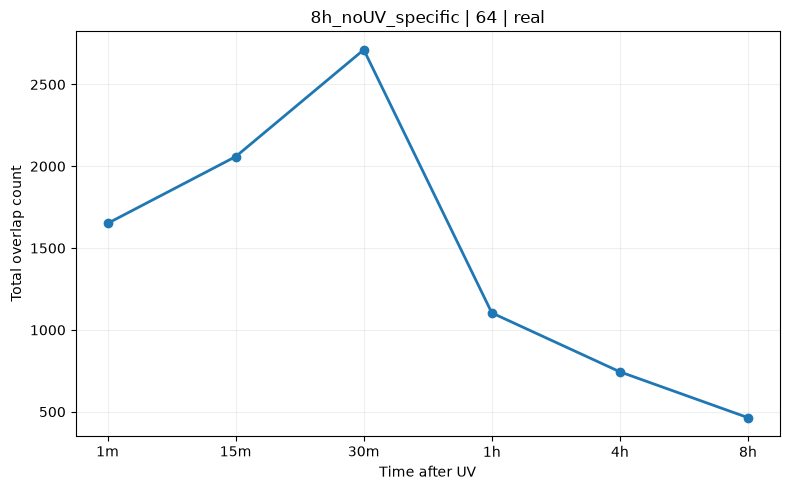

Saved 10 plots to: /cta/users/guneyn23/non_windowed/distribution_plots/overtime_total_overlap_counts/real


In [17]:
def plot_overtime_total_overlaps(kind):
    output_dir = PLOT_DIR / 'overtime_total_overlap_counts' / kind
    output_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for peak_set in PEAK_SETS:
        for damage in DAMAGES:
            selected = overtime_overlap_summary[
                (overtime_overlap_summary['peak_set'] == peak_set)
                & (overtime_overlap_summary['damage'] == damage)
                & (overtime_overlap_summary['kind'] == kind)
            ].sort_values('time')
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.plot(selected['time'].astype(str), selected['total_overlaps'], marker='o', linewidth=2)
            ax.set_xlabel('Time after UV')
            ax.set_ylabel('Total overlap count')
            ax.set_title(f'{peak_set} | {damage} | {kind}')
            ax.ticklabel_format(axis='y', style='plain')
            ax.grid(alpha=0.2)
            fig.tight_layout()
            output = output_dir / f'{peak_set}__{damage}__{kind}_total_overlap_count.png'
            fig.savefig(output, dpi=300, bbox_inches='tight')
            plt.show()
            plt.close(fig)
            saved.append(output)
    print(f'Saved {len(saved)} plots to: {output_dir}')
    return saved

real_overtime_overlap_plots = plot_overtime_total_overlaps('real')

### Simulated total overlap counts

In [ ]:
sim_overtime_overlap_plots = plot_overtime_total_overlaps('sim')

## Excluded negative relative RPKM summary

For each distribution, this table reports the initial peak count, the number excluded for having negative relative RPKM, and the excluded percentage of the initial peaks.

In [8]:
negative_summary_rows = []

for kind in ['real', 'sim']:
    for peak_set in PEAK_SETS:
        for damage in DAMAGES:
            for time in TIMES:
                path = relative_path(peak_set, damage, time, kind)
                data = pd.read_csv(path, sep='\t', header=None)
                numeric = pd.to_numeric(data.iloc[:, -1], errors='coerce').replace(
                    [np.inf, -np.inf], np.nan
                )
                finite = numeric.dropna()
                negative = finite[finite < 0]
                negative_summary_rows.append({
                    'peak_set': peak_set,
                    'damage': damage,
                    'time': time,
                    'kind': kind,
                    'initial_peak_count': len(data),
                    'excluded_negative_peak_count': len(negative),
                    'excluded_negative_ratio_percent': (
                        100 * len(negative) / len(data) if len(data) else np.nan
                    ),
                })

negative_summary = pd.DataFrame(negative_summary_rows)
negative_summary_path = PLOT_DIR / 'excluded_negative_relative_rpkm_summary.tsv'
negative_summary.to_csv(negative_summary_path, sep='\t', index=False)
print(f'Written: {negative_summary_path}')
negative_summary


Written: /cta/users/guneyn23/non_windowed/distribution_plots/excluded_negative_relative_rpkm_summary.tsv


,peak_set,damage,time,kind,initial_peak_count,excluded_negative_peak_count,excluded_negative_ratio_percent
0,noUV_IDR_ATAC,CPD,15m,real,48911,20081,41.056204
1,noUV_IDR_ATAC,CPD,30m,real,48911,21136,43.213183
2,noUV_IDR_ATAC,CPD,1h,real,48911,18643,38.116170
3,noUV_IDR_ATAC,CPD,4h,real,48911,16193,33.107072
4,noUV_IDR_ATAC,CPD,8h,real,48911,12149,24.838993
...,...,...,...,...,...,...,...
95,8h_noUV_specific,64,15m,sim,485,211,43.505155
96,8h_noUV_specific,64,30m,sim,485,223,45.979381
97,8h_noUV_specific,64,1h,sim,485,158,32.577320
98,8h_noUV_specific,64,4h,sim,485,233,48.041237


## Real relative RPKM distributions

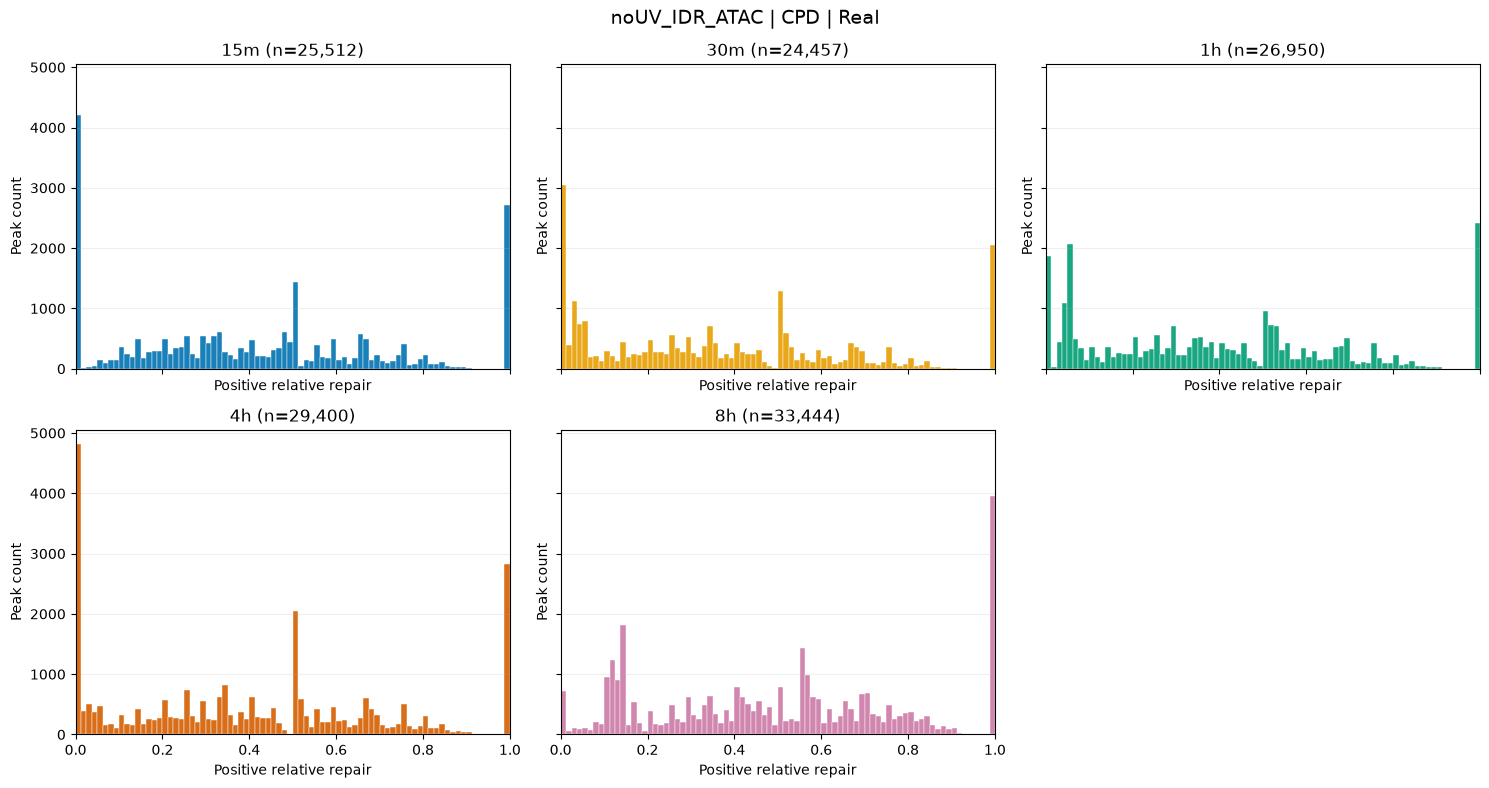

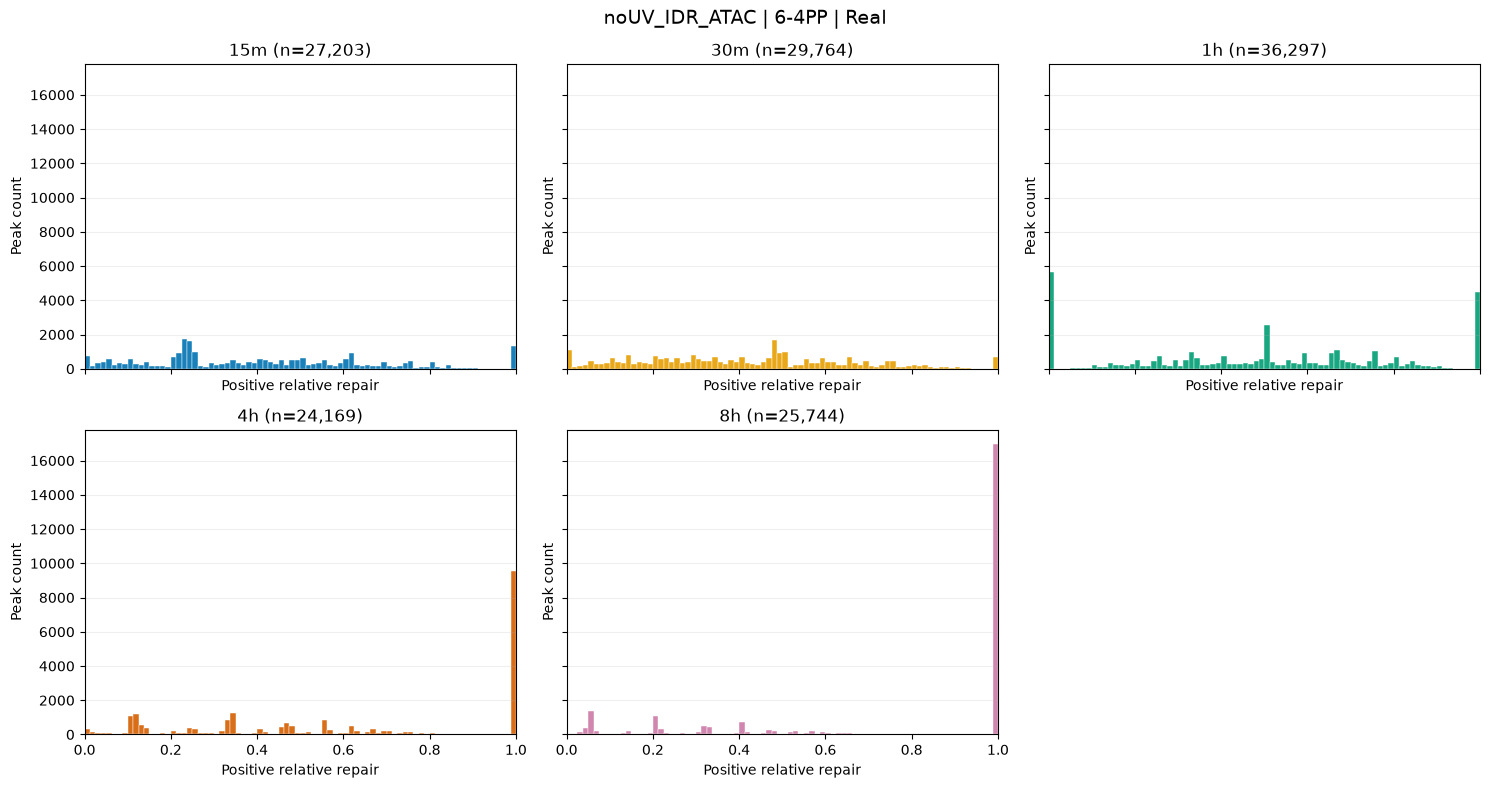

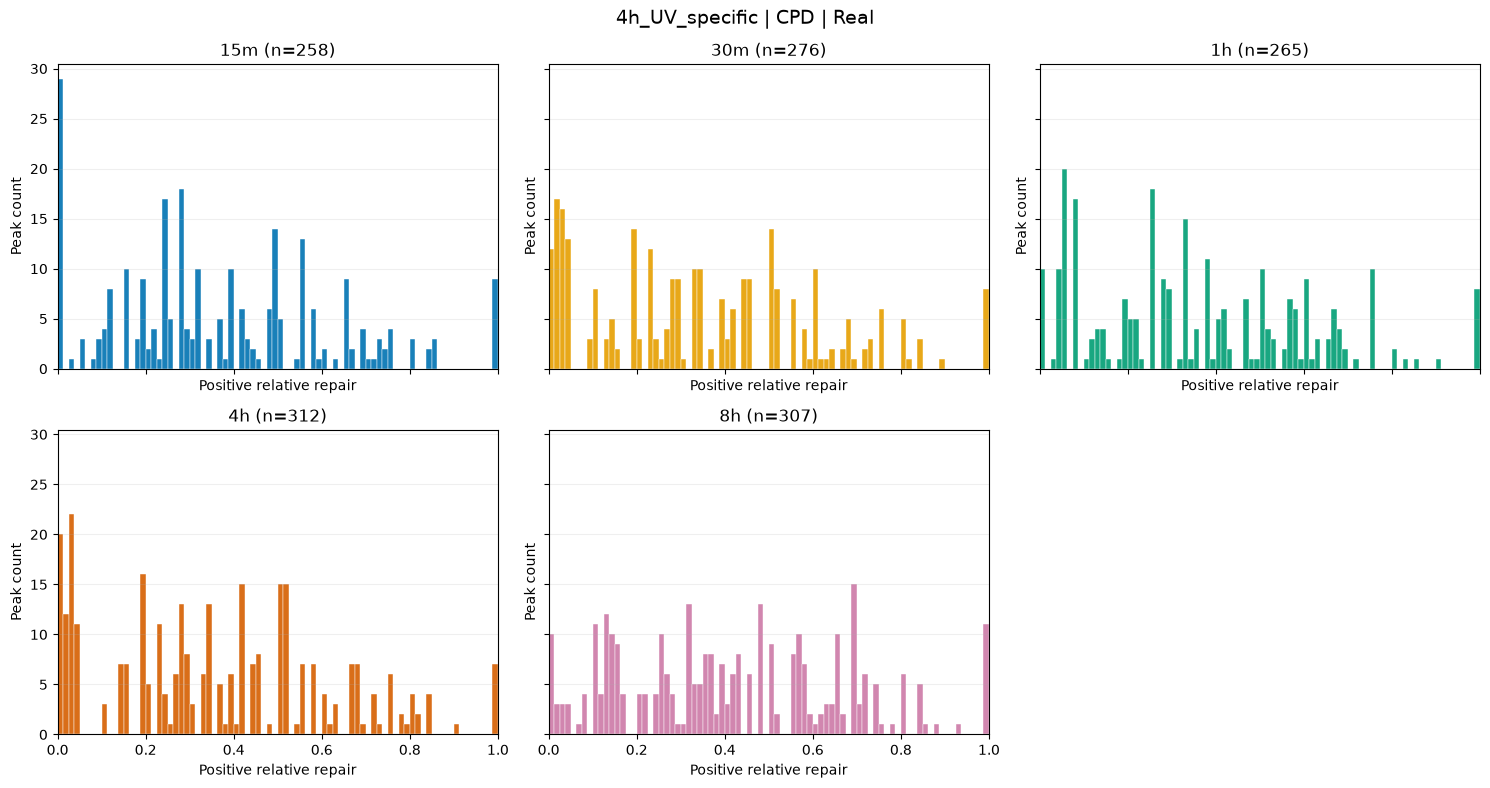

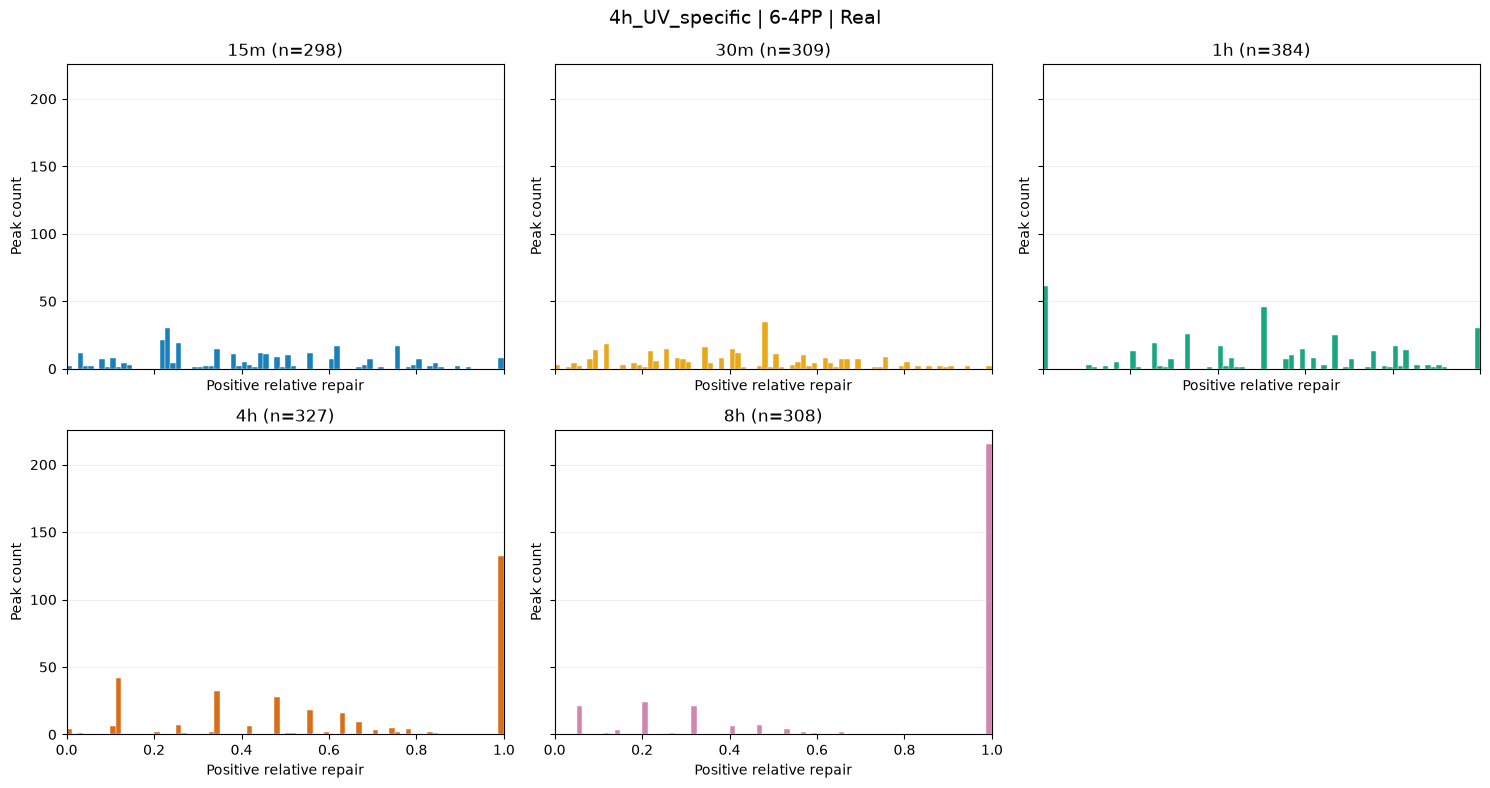

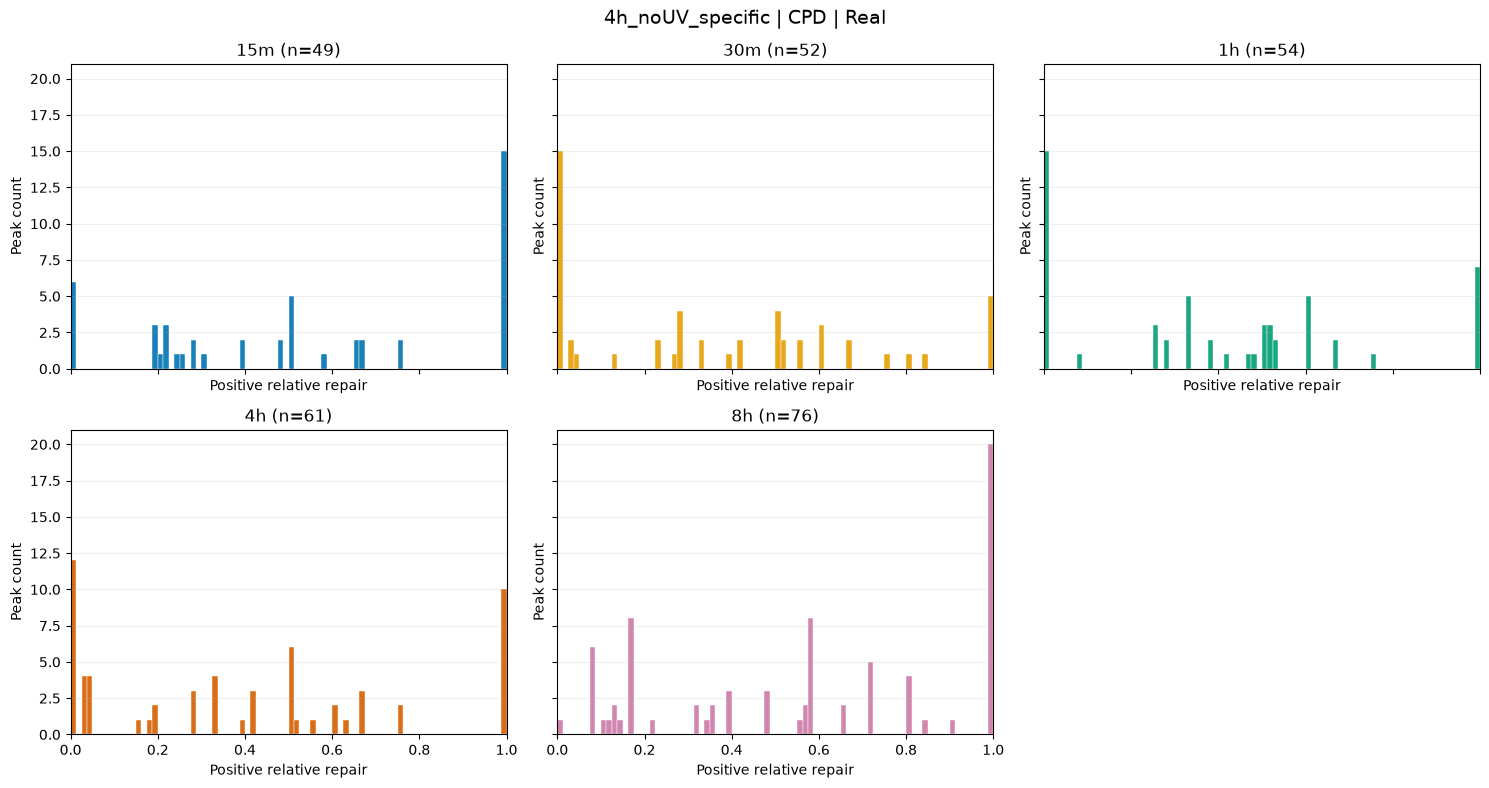

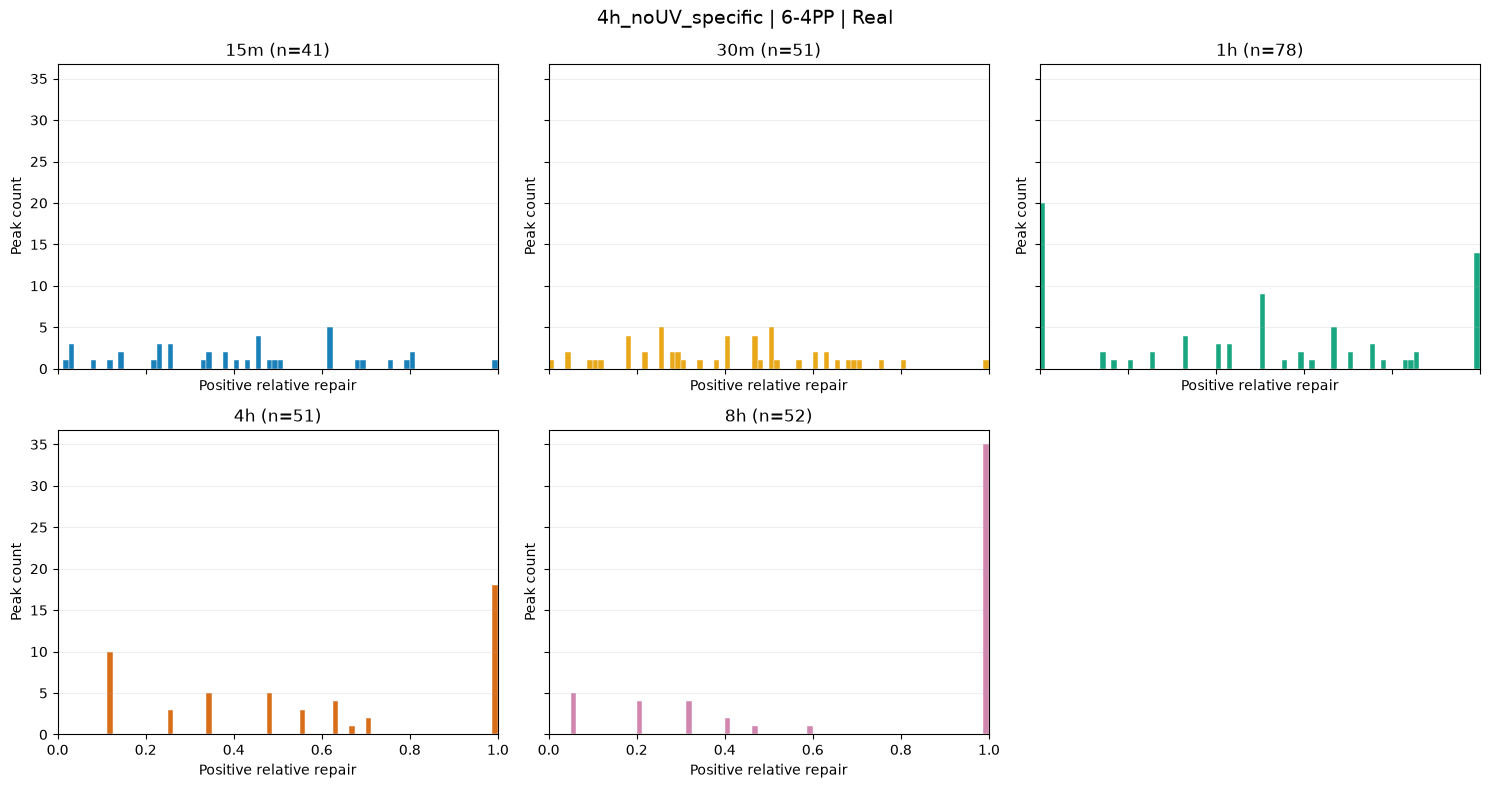

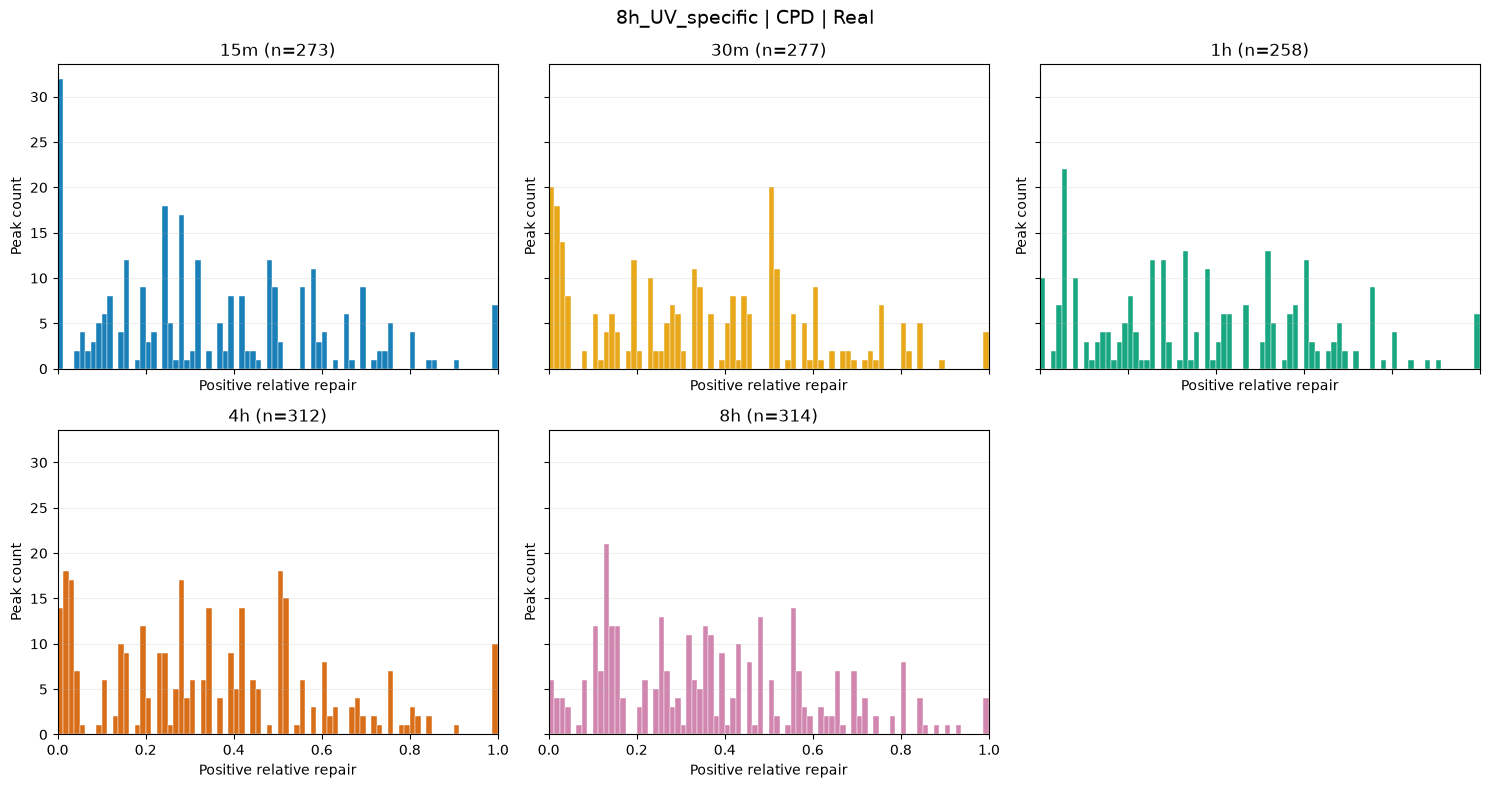

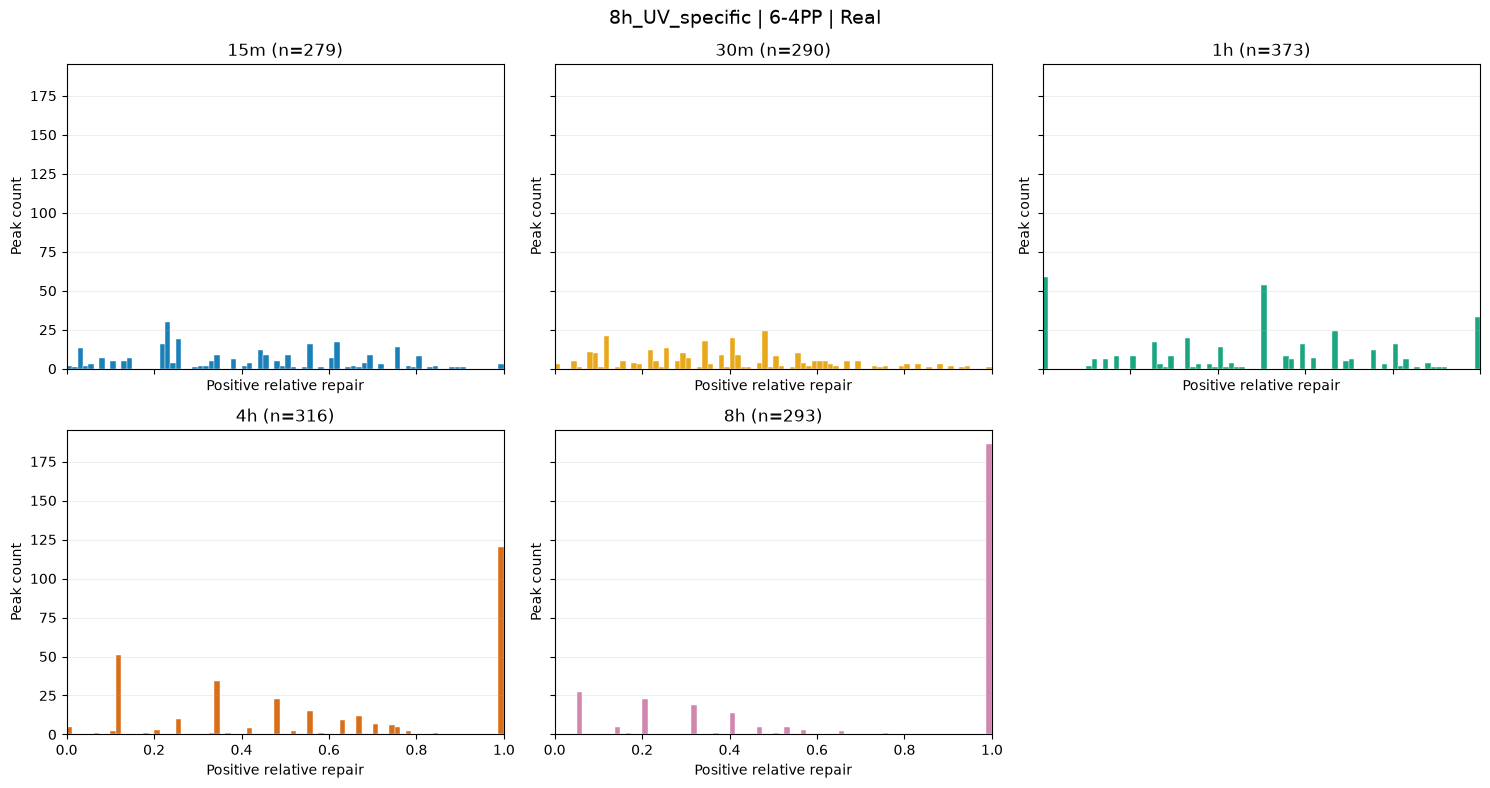

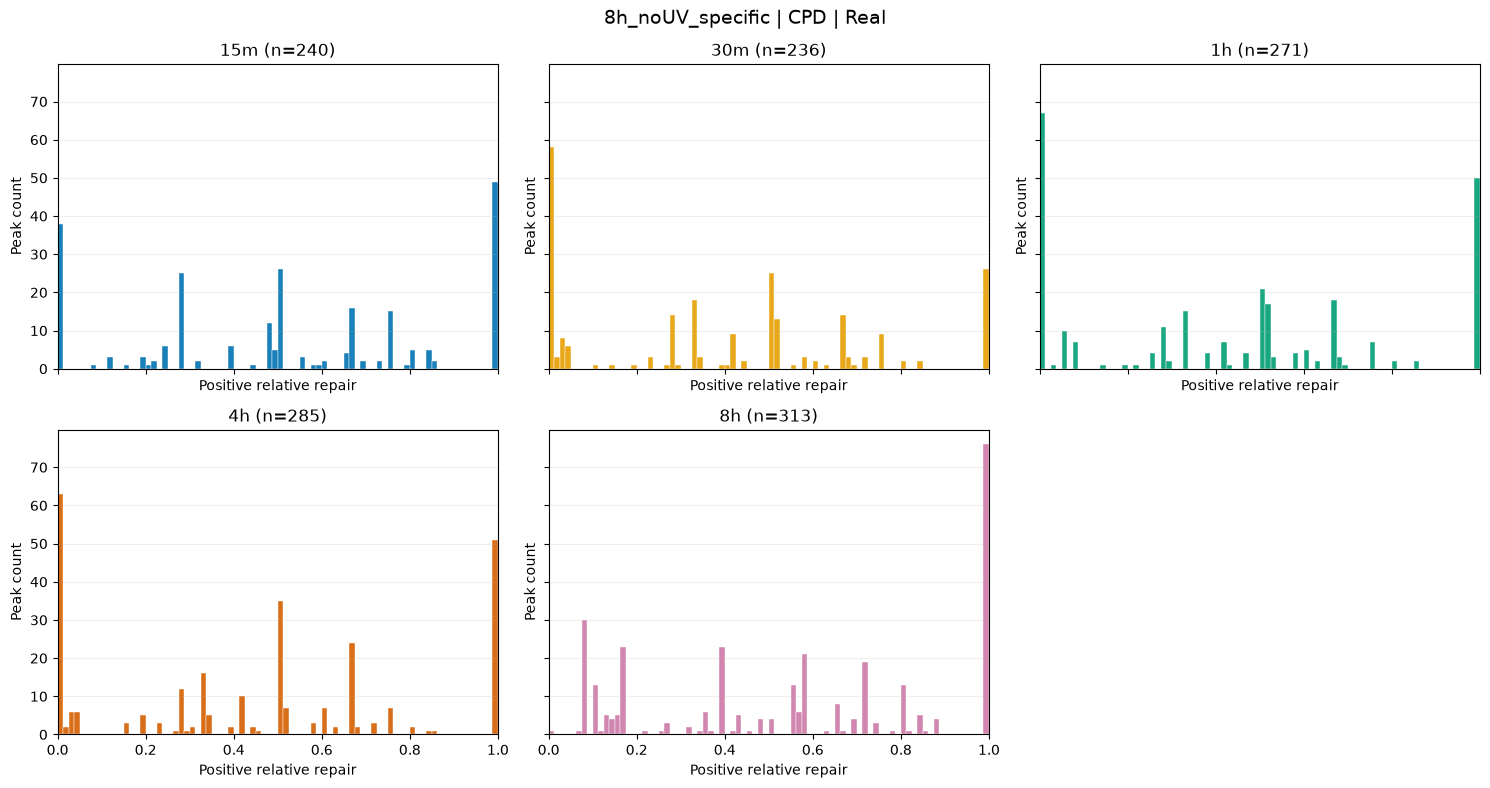

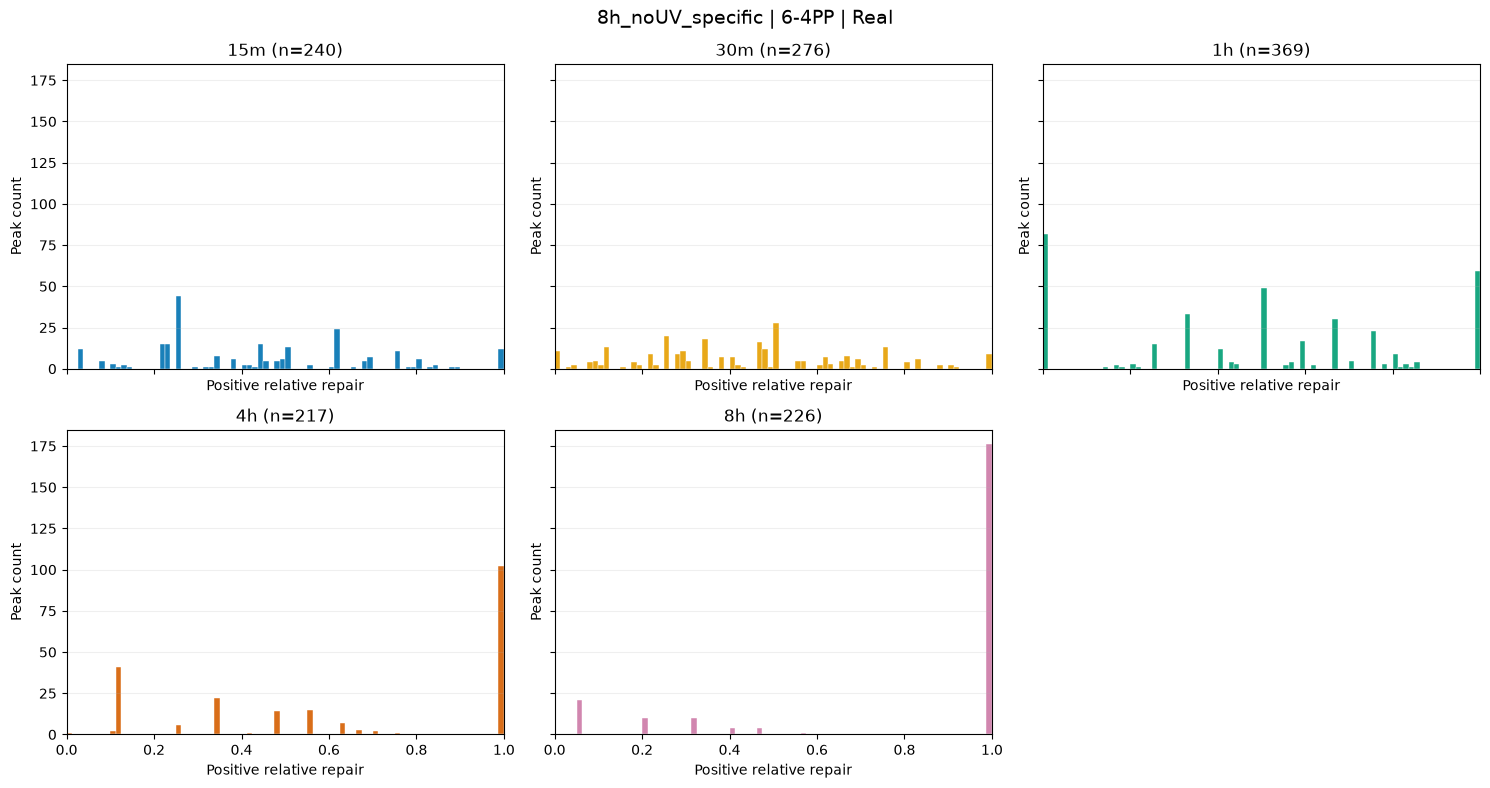

Saved 10 real plots to: /cta/users/guneyn23/non_windowed/distribution_plots/real


In [9]:
real_plots = plot_distributions('real')

## Simulated relative RPKM distributions

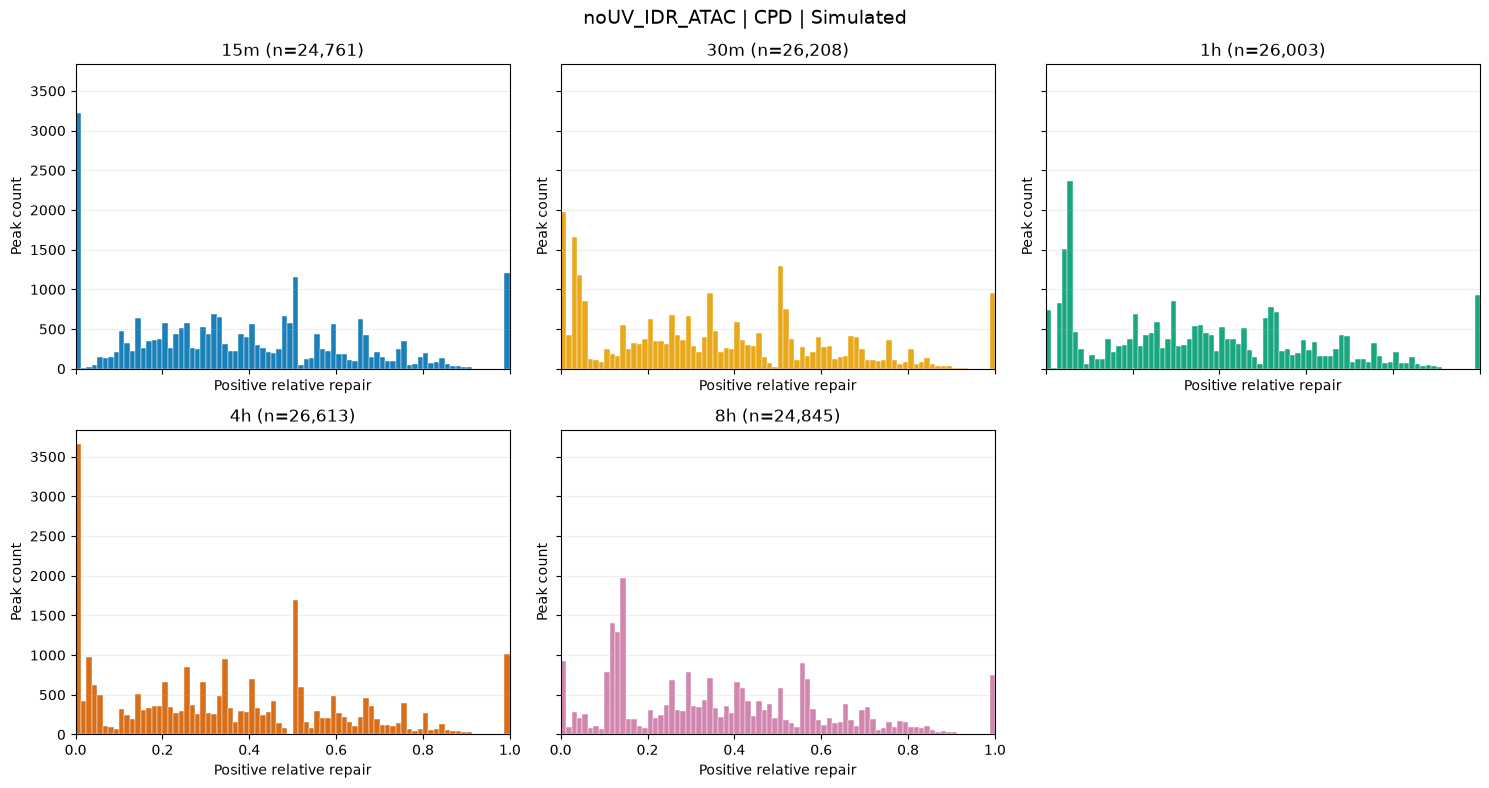

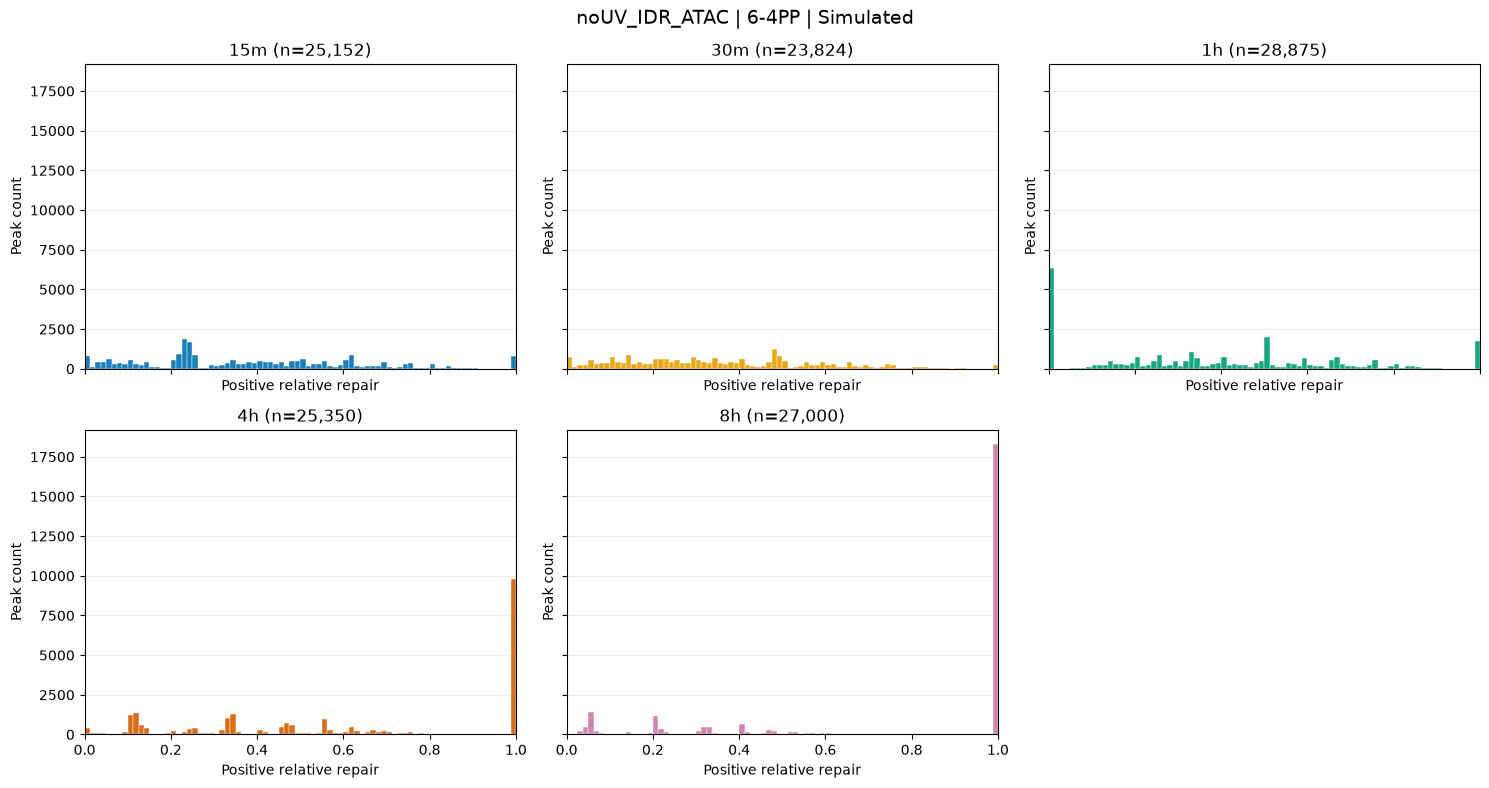

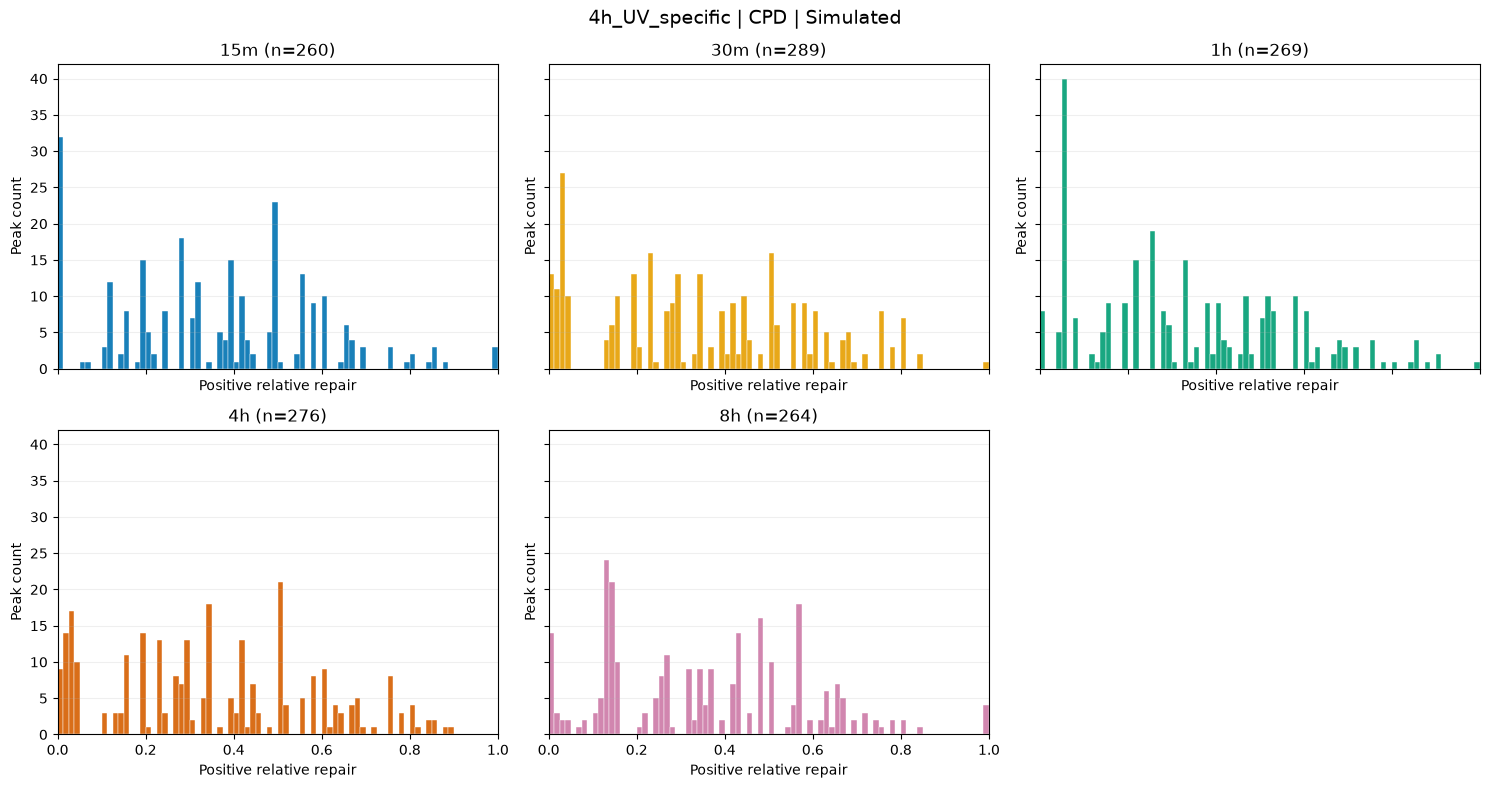

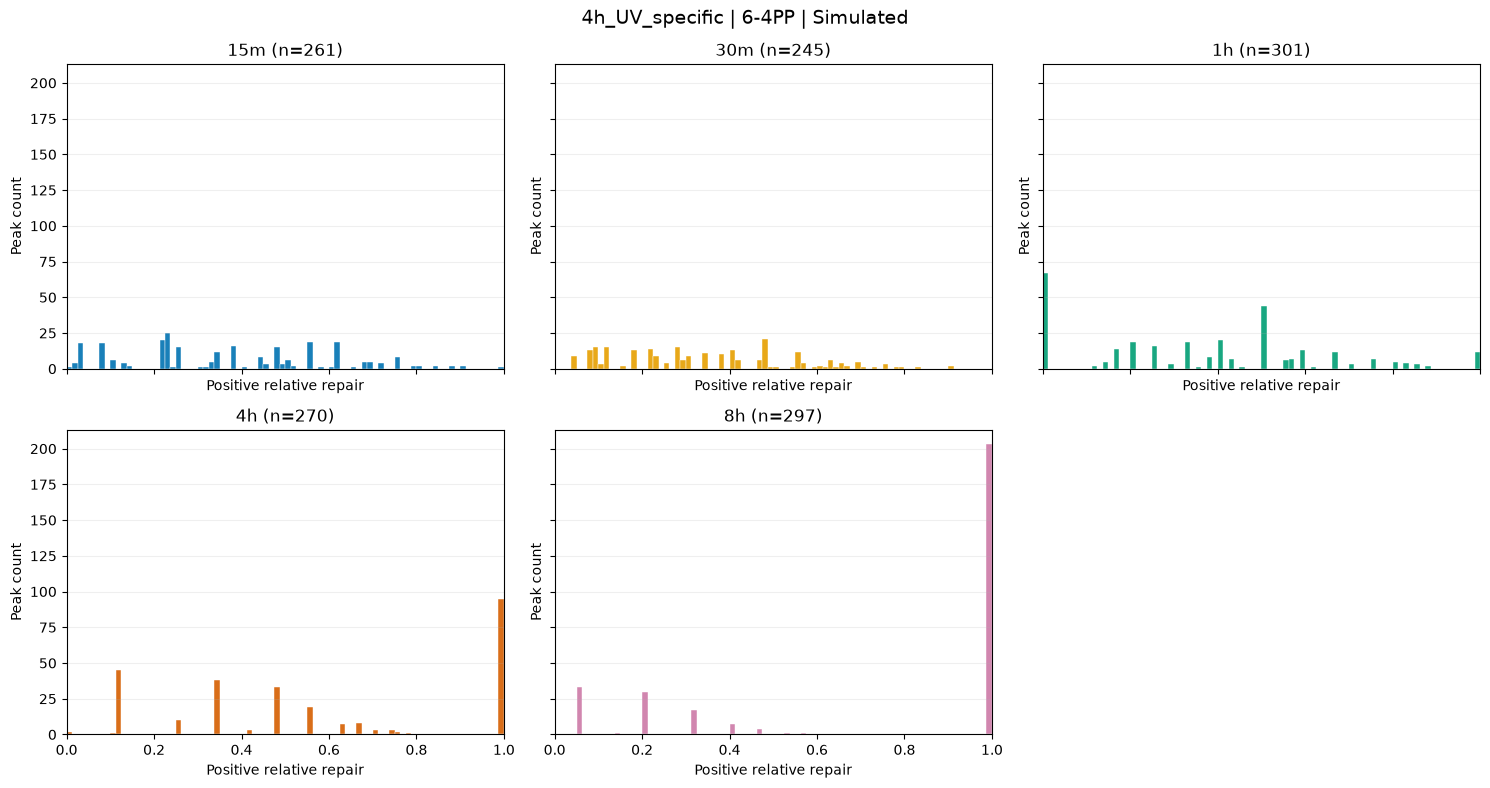

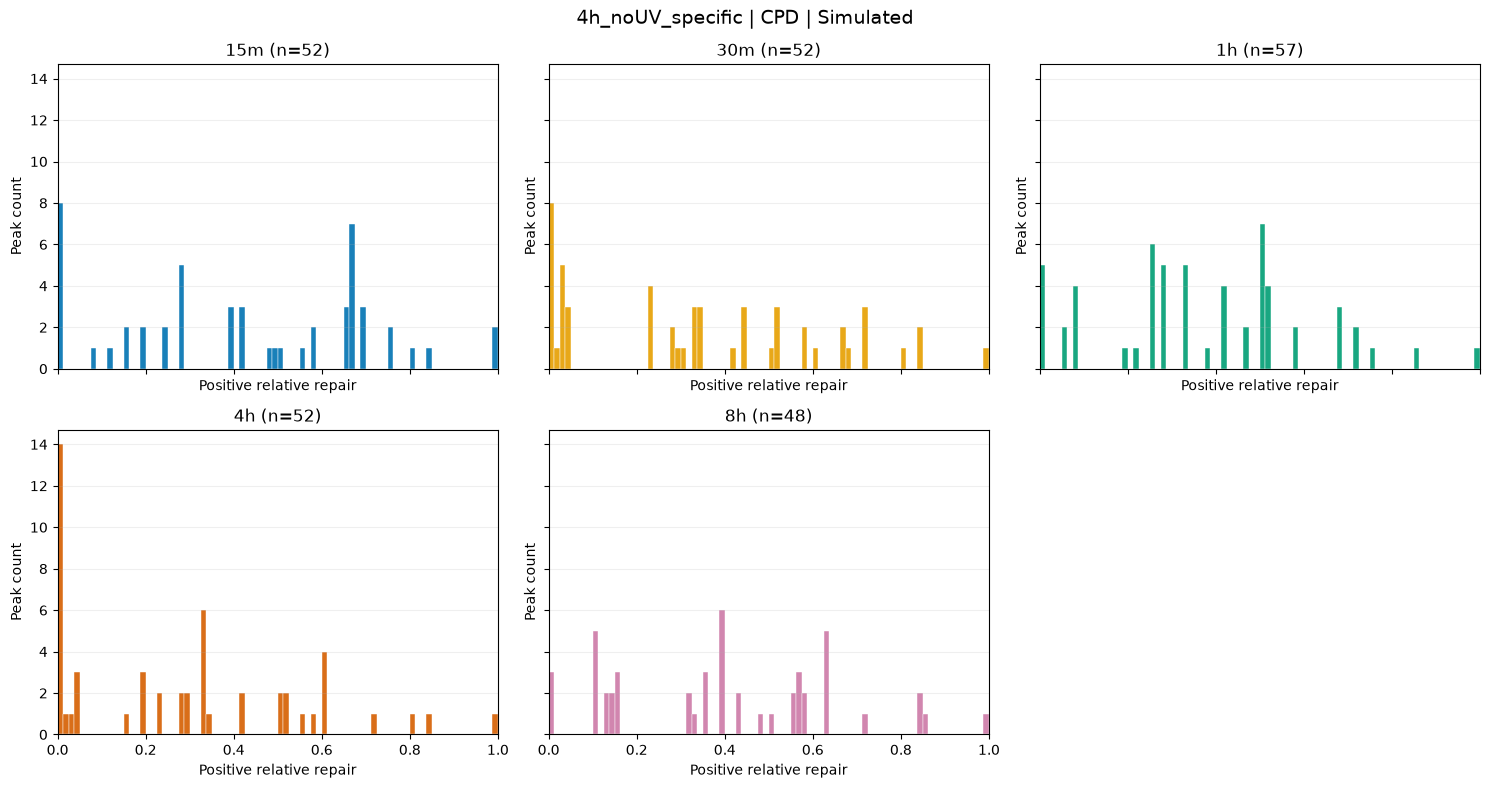

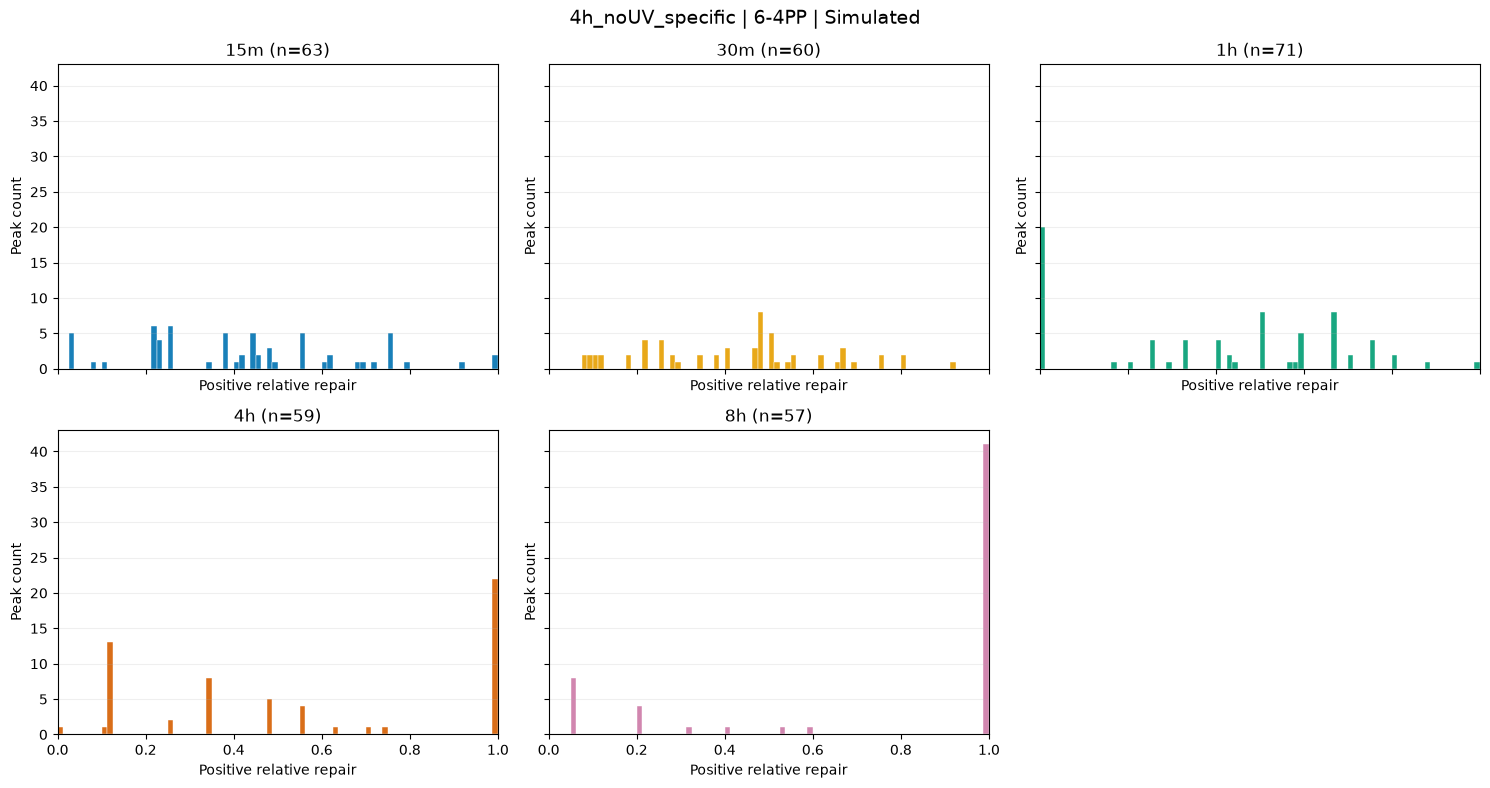

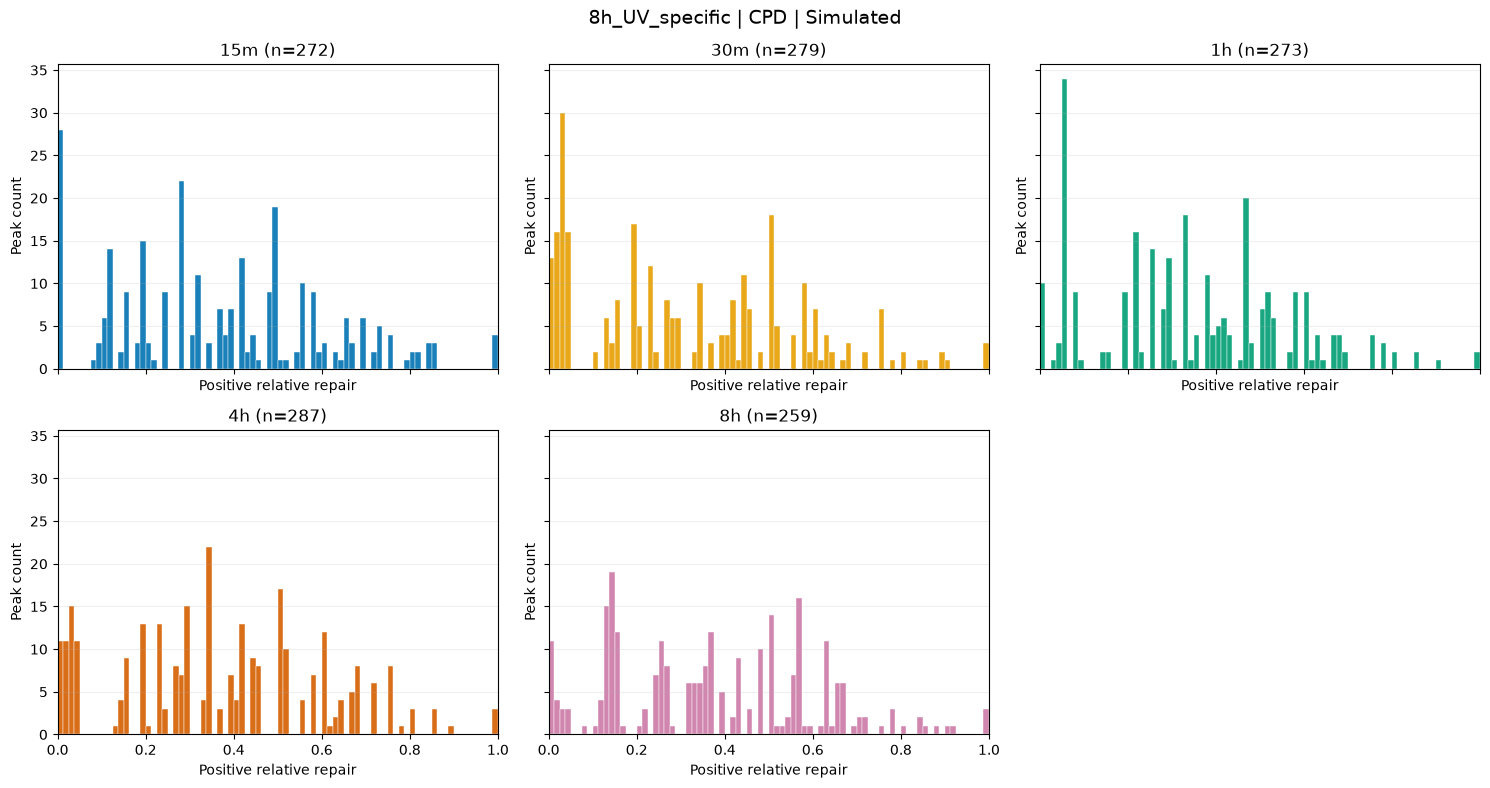

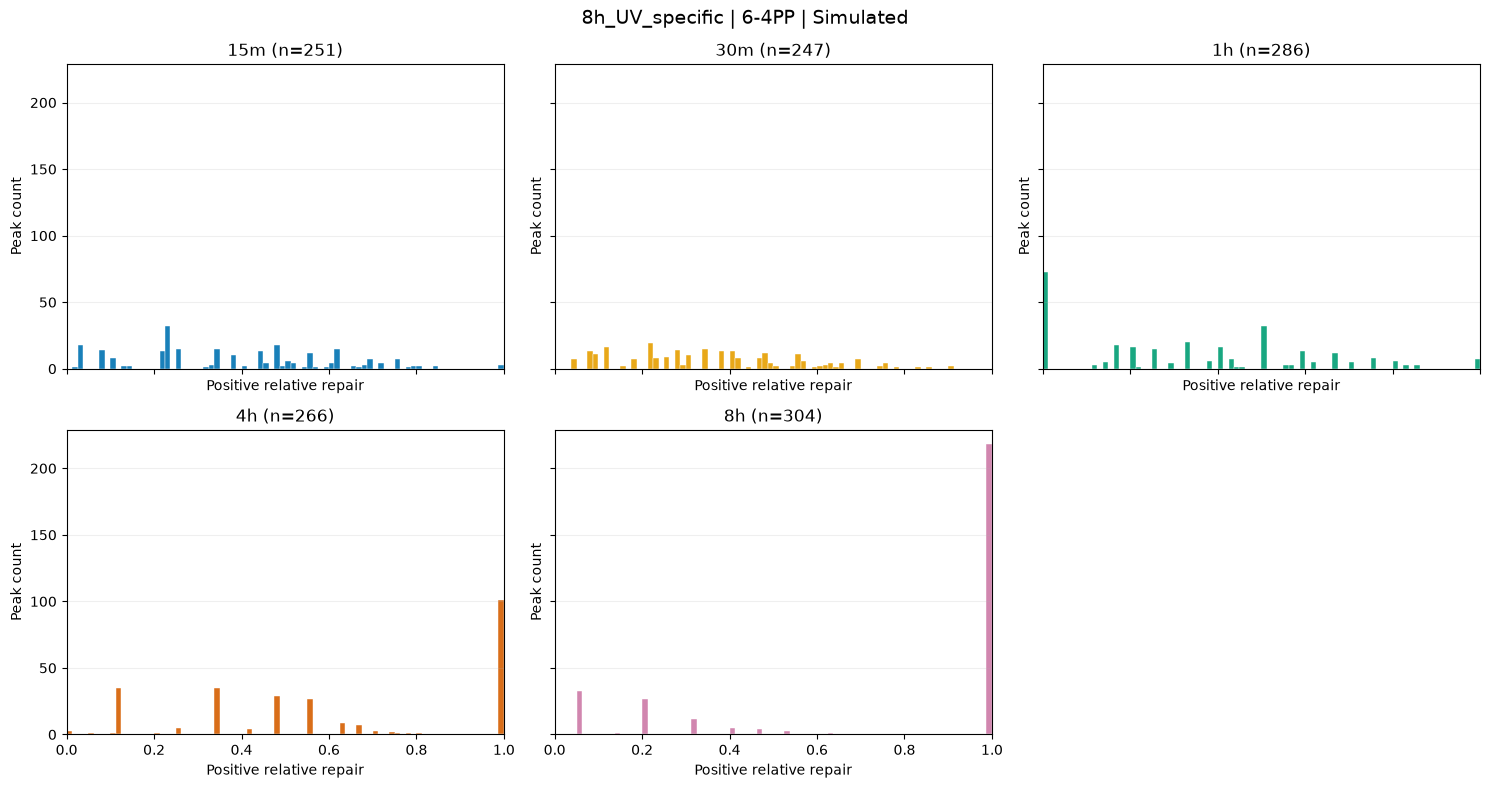

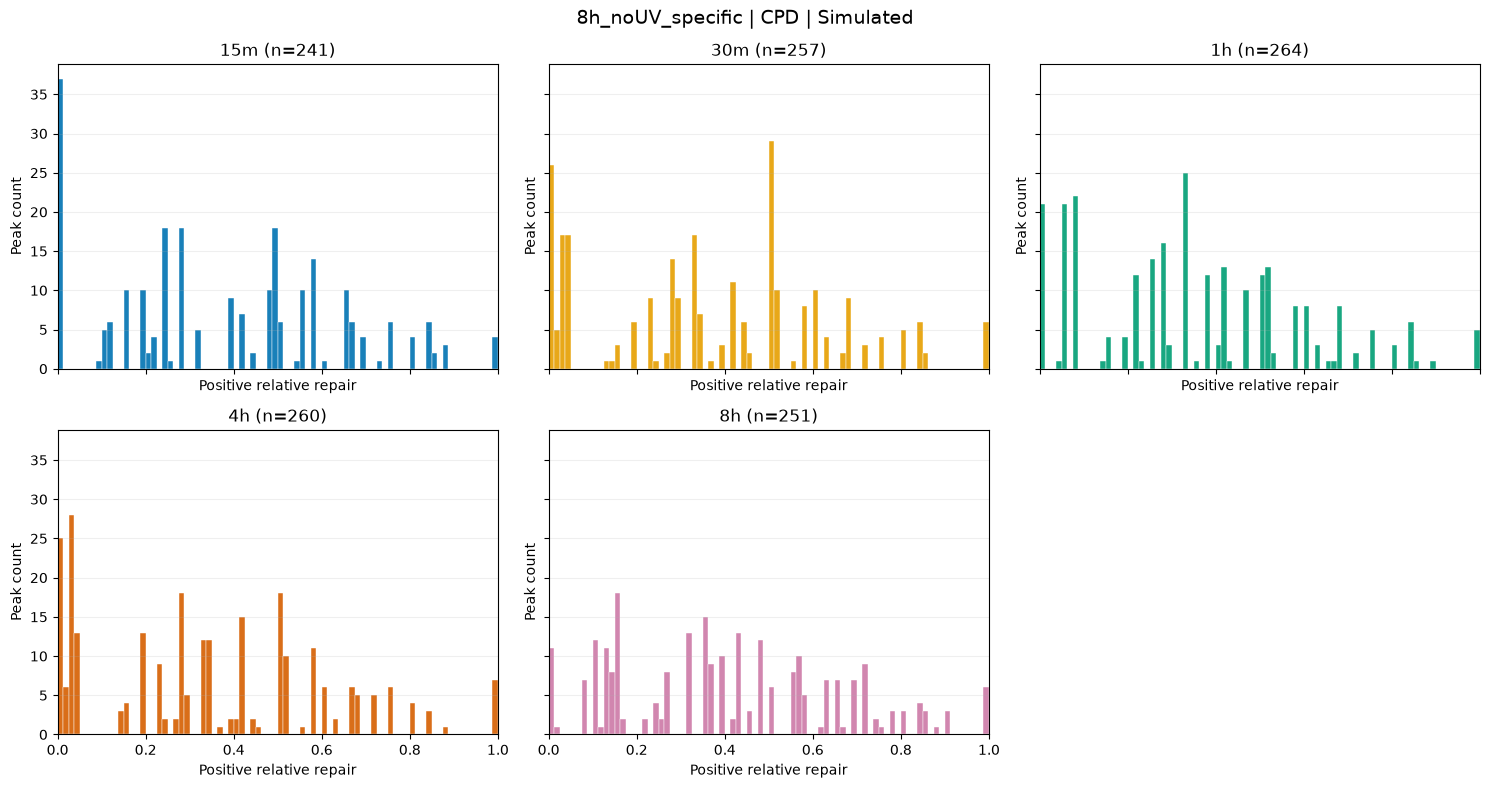

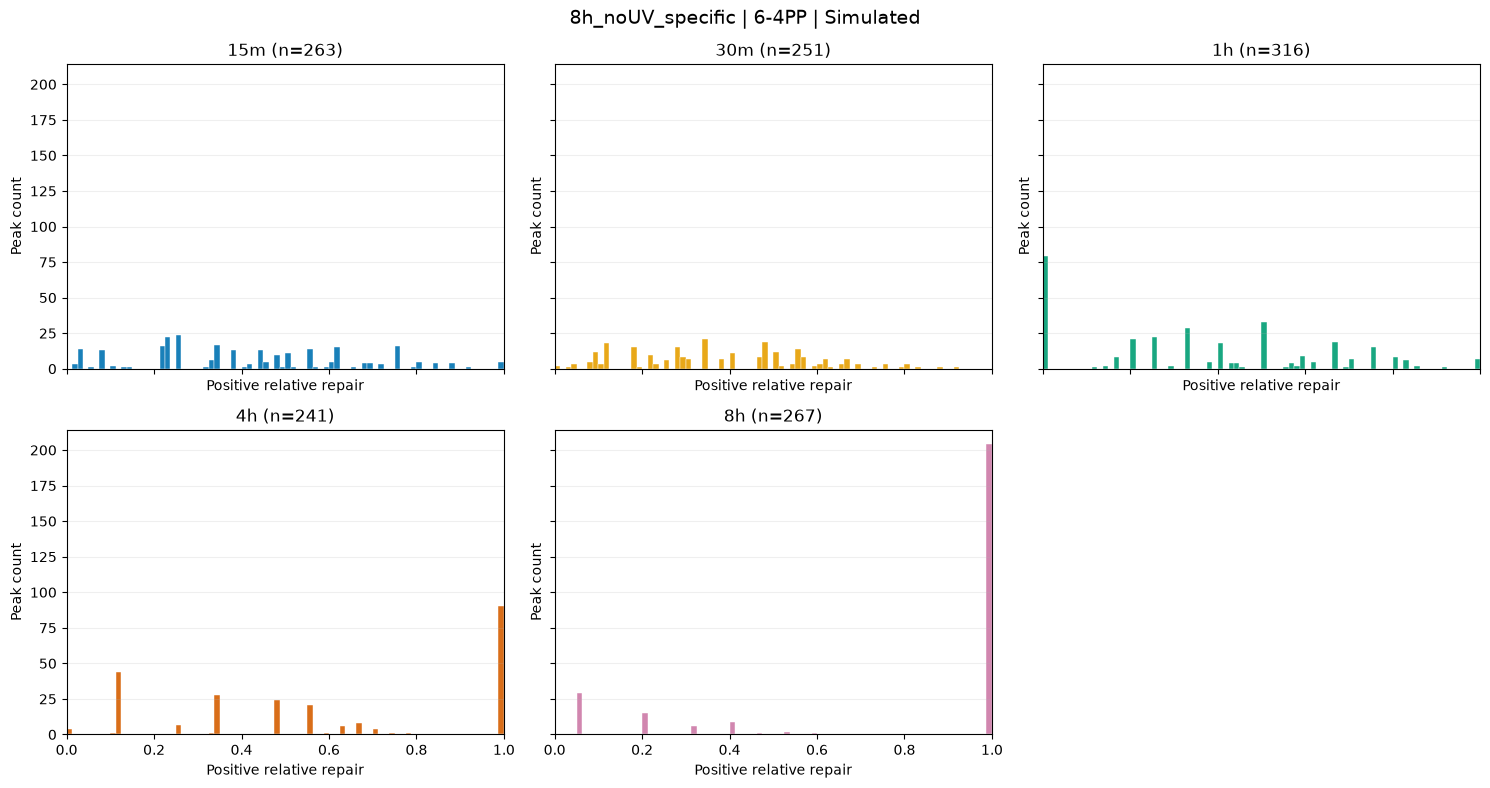

Saved 10 sim plots to: /cta/users/guneyn23/non_windowed/distribution_plots/sim


In [10]:
simulated_plots = plot_distributions('sim')

## Fully repaired (relative RPKM = 1) timepoint Venn diagrams

Run the SLURM first to extract relative RPKM = 1.00 BEDs and reciprocal full overlaps (`bedtools intersect -f 1 -F 1`). This cell only reads those BED files and saves early (15m/30m/1h) and late (1h/4h/8h) Venn diagrams.

In [ ]:
from matplotlib.patches import Circle

VENN_OUTPUT = BASE / 'non_windowed/fully_repaired_timepoint_venn'
VENN_PEAK_SETS = PEAK_SETS  # yalnızca noUV IDR için: ['noUV_IDR_ATAC']
VENN_GROUPS = {'early_15m_30m_1h': ('15m', '30m', '1h'), 'late_1h_4h_8h': ('1h', '4h', '8h')}

def read_bed_intervals(path):
    if not path.exists():
        raise FileNotFoundError(f'Run the fully repaired SLURM first: {path}')
    if path.stat().st_size == 0:
        return set()
    bed = pd.read_csv(path, sep='\t', header=None, usecols=[0, 1, 2])
    return set(map(tuple, bed.itertuples(index=False, name=None)))

def draw_three_set_venn(sets, labels, title, output_png):
    a, b, c = sets
    counts = {
        '100': len(a - b - c), '010': len(b - a - c), '001': len(c - a - b),
        '110': len((a & b) - c), '101': len((a & c) - b),
        '011': len((b & c) - a), '111': len(a & b & c),
    }
    fig, ax = plt.subplots(figsize=(7, 6))
    for xy, color in [((0.40, 0.56), '#4C78A8'), ((0.60, 0.56), '#F58518'), ((0.50, 0.38), '#54A24B')]:
        ax.add_patch(Circle(xy, 0.27, facecolor=color, edgecolor=color, alpha=0.35, lw=2))
    positions = {'100': (0.27, 0.59), '010': (0.73, 0.59), '001': (0.50, 0.23), '110': (0.50, 0.65), '101': (0.38, 0.40), '011': (0.62, 0.40), '111': (0.50, 0.49)}
    for key, position in positions.items():
        ax.text(*position, str(counts[key]), ha='center', va='center', fontsize=12)
    ax.text(0.20, 0.84, f'{labels[0]} (n={len(a):,})', color='#2F5D8A', ha='center')
    ax.text(0.80, 0.84, f'{labels[1]} (n={len(b):,})', color='#B85C00', ha='center')
    ax.text(0.50, 0.04, f'{labels[2]} (n={len(c):,})', color='#327A32', ha='center')
    ax.set(xlim=(0, 1), ylim=(0, 1), aspect='equal', title=title)
    ax.axis('off')
    fig.tight_layout()
    fig.savefig(output_png, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return counts

VENN_OUTPUT.mkdir(parents=True, exist_ok=True)
summary = []
for peak_set in VENN_PEAK_SETS:
    for damage in DAMAGES:
        for kind in ('real', 'sim'):
            out_dir = VENN_OUTPUT / peak_set / damage / kind
            out_dir.mkdir(parents=True, exist_ok=True)
            interval_sets = {
                time: read_bed_intervals(out_dir / f'{time}_fully_repaired.bed')
                for time in TIMES
            }
            for group_name, group_times in VENN_GROUPS.items():
                if not set(group_times).issubset(interval_sets):
                    continue
                counts = draw_three_set_venn(
                    [interval_sets[t] for t in group_times], group_times,
                    f'{peak_set} | {damage} | {kind} | relative RPKM = 1',
                    out_dir / f'{group_name}_fully_repaired_venn.png',
                )
                summary.append({'peak_set': peak_set, 'damage': damage, 'kind': kind, 'comparison': group_name, **counts})

summary_df = pd.DataFrame(summary)
summary_df.to_csv(VENN_OUTPUT / 'fully_repaired_venn_counts.tsv', sep='\t', index=False)
print(f'Saved {len(summary_df)} Venn diagrams and count summary to: {VENN_OUTPUT}')
summary_df